In [4]:
# =========================
# 0. SETUP Y DESCARGA — OpenSubtitles v2018 (EN-ES), vía OPUS
# Versión con muestreo por reservorio + liberación periódica de memoria
# =========================
import os, io, zipfile, random, re, collections, gc
import requests
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)

DATA_DIR = "data_1m"
os.makedirs(DATA_DIR, exist_ok=True)
URL = "https://object.pouta.csc.fi/OPUS-OpenSubtitles/v2018/moses/en-es.txt.zip"
ZIP_PATH = os.path.join(DATA_DIR, "en-es.txt.zip")

if not os.path.exists(ZIP_PATH):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(URL, headers=headers, timeout=180)
    r.raise_for_status()
    with open(ZIP_PATH, "wb") as f:
        f.write(r.content)
print(f"Zip: {os.path.getsize(ZIP_PATH)/1e9:.2f} GB")

with zipfile.ZipFile(ZIP_PATH) as z:
    names = z.namelist()
    print("Archivos en el zip:", names)
    en_name = next(n for n in names if n.endswith(".en"))
    es_name = next(n for n in names if n.endswith(".es"))

    TARGET_N = 1_000_000
    rng = random.Random(SEED)
    reservoir = []
    n_seen = 0
    n_empty = 0

    with z.open(en_name) as fen, z.open(es_name) as fes:
        for i, (be, bs) in enumerate(zip(fen, fes)):
            e = be.decode("utf-8", errors="replace").rstrip("\n")
            s = bs.decode("utf-8", errors="replace").rstrip("\n")
            if e == "" or s == "":
                n_empty += 1
                continue
            n_seen += 1
            if len(reservoir) < TARGET_N:
                reservoir.append((e, s))
            else:
                j = rng.randint(0, n_seen - 1)
                if j < TARGET_N:
                    reservoir[j] = (e, s)
            if i % 5_000_000 == 0 and i > 0:
                gc.collect()
                print(f"  ...{i:,} líneas leídas | reservorio={len(reservoir):,}")

print(f"\nLíneas totales recorridas: {i+1:,}")
print(f"Líneas vacías descartadas (en cualquier lado): {n_empty:,}")
print(f"Líneas no vacías válidas: {n_seen:,}")
print(f"Tamaño del reservorio (muestra final): {len(reservoir):,}")

df_raw_1m = pd.DataFrame(reservoir, columns=["english", "spanish"])
print(f"\nMuestra final: {len(df_raw_1m):,} pares")
display(df_raw_1m.sample(10, random_state=SEED))

Zip: 1.89 GB
Archivos en el zip: ['OpenSubtitles.en-es.en', 'OpenSubtitles.en-es.es', 'OpenSubtitles.en-es.ids', 'README']
  ...5,000,000 líneas leídas | reservorio=1,000,000
  ...10,000,000 líneas leídas | reservorio=1,000,000
  ...15,000,000 líneas leídas | reservorio=1,000,000
  ...20,000,000 líneas leídas | reservorio=1,000,000
  ...25,000,000 líneas leídas | reservorio=1,000,000
  ...30,000,000 líneas leídas | reservorio=1,000,000
  ...35,000,000 líneas leídas | reservorio=1,000,000
  ...40,000,000 líneas leídas | reservorio=1,000,000
  ...45,000,000 líneas leídas | reservorio=1,000,000
  ...50,000,000 líneas leídas | reservorio=1,000,000
  ...55,000,000 líneas leídas | reservorio=1,000,000
  ...60,000,000 líneas leídas | reservorio=1,000,000

Líneas totales recorridas: 61,434,251
Líneas vacías descartadas (en cualquier lado): 0
Líneas no vacías válidas: 61,434,251
Tamaño del reservorio (muestra final): 1,000,000

Muestra final: 1,000,000 pares


,english,spanish
987231,I want just a few minutes where we're not in a panic.,Unos cuantos minutos en que no seamos presas del pánico.
79954,YOU ONLY SAY THAT WHEN PEOPLE,SOLO DECIR QUE CUANDO LA GENTE
567130,A bad dream ...,Un mal sueño ...
500891,I don't mind.,"-No, estoy bien."
55399,Thank you.,Gracias.
135049,What about the baby?,¿Qué hay con el bebé?
733378,"Besides, he's always been more like a best friend to me, anyway.","Además, él siempre ha sido un muy buen amigo."
732057,"""where I come from, who I am""",¿De dónde vengo? ¿Quién soy?
51333,* but you're onto me *,* but you're onto me *
731479,"Let's check what Fuss is doing, you stupid morons!","¡Vamos a ver qué viene tanto revuelo haciendo, idiotas estúpidos!"


In [5]:
# =========================
# CALIDAD DE DATOS — diagnóstico adaptado a subtítulos
# =========================
N = len(df_raw_1m)
en, es = df_raw_1m["english"], df_raw_1m["spanish"]

print(f"Total de pares: {N:,}\n")

# --- Duplicados exactos ---
dup = df_raw_1m.duplicated(subset=["english", "spanish"], keep="first")
print(f"=== Duplicados exactos (EN+ES) ===")
print(f"Filas duplicadas: {dup.sum():,} ({dup.mean()*100:.2f}%)")
print("Ejemplos de pares que más se repiten:")
print(df_raw_1m.groupby(["english", "spanish"]).size().sort_values(ascending=False).head(15).to_string())

# --- Inglés == Español (no traducido) ---
same = en.str.strip().str.lower() == es.str.strip().str.lower()
print(f"\n=== EN == ES (posible no-traducido) === {same.sum():,} ({same.mean()*100:.2f}%)")
display(df_raw_1m[same].sample(min(10, same.sum()), random_state=SEED))

# --- Todo en mayúsculas ---
has_letters = lambda s: s.str.contains(r"[A-Za-zÀ-ÿ]")
allcaps_en = en[has_letters(en)].apply(lambda s: s == s.upper())
allcaps_es = es[has_letters(es)].apply(lambda s: s == s.upper())
print(f"\n=== Todo en mayúsculas === EN: {allcaps_en.sum():,} ({allcaps_en.mean()*100:.2f}%) | ES: {allcaps_es.sum():,} ({allcaps_es.mean()*100:.2f}%)")
display(df_raw_1m.loc[allcaps_en[allcaps_en].sample(min(8, allcaps_en.sum()), random_state=SEED).index])

# --- Guion de diálogo al inicio ---
dash_en = en.str.match(r"^\s*-\s*\S")
dash_es = es.str.match(r"^\s*-\s*\S")
print(f"\n=== Empieza con guion de diálogo === EN: {dash_en.sum():,} ({dash_en.mean()*100:.2f}%) | ES: {dash_es.sum():,} ({dash_es.mean()*100:.2f}%)")
display(df_raw_1m[dash_en | dash_es].sample(8, random_state=SEED))

# --- Solo puntuación / sin ninguna letra ---
no_letter_en = ~has_letters(en)
no_letter_es = ~has_letters(es)
print(f"\n=== Sin ninguna letra (solo signos/números) === EN: {no_letter_en.sum():,} ({no_letter_en.mean()*100:.2f}%) | ES: {no_letter_es.sum():,} ({no_letter_es.mean()*100:.2f}%)")
display(df_raw_1m[no_letter_en | no_letter_es].sample(min(10, (no_letter_en | no_letter_es).sum()), random_state=SEED))

# --- Restos de HTML / marcado de subtítulos ---
html_en = en.str.contains(r"<[^>]+>|\{[^}]+\}")
html_es = es.str.contains(r"<[^>]+>|\{[^}]+\}")
print(f"\n=== Restos de etiquetas (HTML/ASS) === EN: {html_en.sum():,} | ES: {html_es.sum():,}")
if html_en.sum() or html_es.sum():
    display(df_raw_1m[html_en | html_es].sample(min(8, (html_en | html_es).sum()), random_state=SEED))

Total de pares: 1,000,000

=== Duplicados exactos (EN+ES) ===
Filas duplicadas: 108,440 (10.84%)
Ejemplos de pares que más se repiten:
english        spanish   
No.            No.           2537
Yeah.          Sí.           2085
What?          ¿Qué?         1823
Thank you.     Gracias.      1757
Yes.           Sí.           1399
- Yeah.        - Sí.         1030
Come on.       Vamos.         916
- No.          - No.          857
- What?        - ¿Qué?        807
I'm sorry.     Lo siento.     770
Thanks.        Gracias.       678
- Yes.         - Sí.          670
Why?           ¿Por qué?      638
No!            ¡No!           636
I don't know.  No lo sé.      594

=== EN == ES (posible no-traducido) === 17,136 (1.71%)


,english,spanish
484569,Oop.,Oop.
233009,"""Tees Maar Khan.""","""Tees Maar Khan."""
937165,Erhart.,Erhart.
918187,- No.,- No.
705066,Nawab Saab.,Nawab Saab.
470628,Oh.,Oh.
615517,Okay.,Okay.
448627,Michiko,Michiko
509507,"No, no.","No, no."
475324,NO.,No.



=== Todo en mayúsculas === EN: 8,278 (0.83%) | ES: 2,552 (0.26%)


,english,spanish
267631,I...,Yo...
791614,BRASS:,¿Fred Applewhite?
506929,WHAT?,¡¿Qué? !
412893,"ALL RIGHT, BUT LOOK-- LOOK AT MY MOM.","Vale, pero mira a mi madre."
847626,"ONE PROBLEM AT A TIME, SAM.","Un problema a la vez, Sam."
255414,NOTHING!,¡Nada!
642572,ANY CHANCE WE COULD TRANSFER HER?,¿Hay alguna posibilidad de que podamos transferirla?
931472,PLACE OF DISHONOR,LUGAR DE LA DESHONRA



=== Empieza con guion de diálogo === EN: 123,415 (12.34%) | ES: 138,496 (13.85%)


,english,spanish
401471,-Sit down.,- Siéntate. - ¡No!
7688,- She isn't home yet.,- Aún no ha llegado a casa.
954060,"- That was not the point of this firm. - Now, what are we...",Este no era el objetivo de este bufete.
889608,Background?,- ¿Antecedentes?
383949,"- Go crazy day, crazy.","- Vaya día de locos, de locos."
935086,- Objection.,- Objeción.
552726,- It's just a date.,Sólo es una cita.
524192,"- I'm fine, Spyros.","- Estoy bien, Spyros."



=== Sin ninguna letra (solo signos/números) === EN: 1,978 (0.20%) | ES: 1,538 (0.15%)


,english,spanish
227100,!,!
551798,"Me, me, me.",#
544730,- Two hundred dollars...,$200.
267851,- 1978.,- 1978.
637814,- 90.,90.
783089,Listen.,!
669261,...,"Bueno, así es la vida. Un beso. Adiós."
244429,!,!
449342,... 497.,... 497.
987839,¶ ¶,¶¶



=== Restos de etiquetas (HTML/ASS) === EN: 113 | ES: 59


,english,spanish
612615,"{\pos(110,260)}Beauty pageants are idiotic,",Los concursos de belleza son idiotas.
401082,"- I do, I do, I do, I do, I do","Ido,Ido, Ido { y:i} I do, I do {y:i}"
489740,{\an5\1cH0000FF}Joseon Governor's Office,Oficina del Gobernador Joseon
460990,We were so worried about you.,{\cH00FFFF}Estábamos tan preocupados por Uds.
729085,"""They will make cemeteries their cathedrals, ""and tombs your cities.""","{\cHFFFFFF}vuestras tumbas."""""
167684,"{pos(192,210)}That sounds good.",Eso suena bien.
588679,Faster!,{\cHFFFFFF}Daos prisa.
858413,"Good. {\, good, good.}{\Well, you know, }I'm probably gonna grab Kirk and head back to the dorm, then.","Bien, bien. Bueno, probablemente vaya a buscar a Kirk y luego vuelva al dormitorio."


In [6]:
# =========================
# DIAGNÓSTICO: ¿el guion de diálogo indica desalineamiento?
# =========================
def n_turns(s):
    # cuenta guiones que empiezan un turno de diálogo (inicio de línea o tras espacio, seguido de texto)
    return len(re.findall(r"(?:^|\s)-\s*\S", s))

turns_en = en.map(n_turns)
turns_es = es.map(n_turns)

print("=== Distribución de nº de turnos detectados ===")
print("EN:", turns_en.value_counts().sort_index().head(5).to_string())
print("ES:", turns_es.value_counts().sort_index().head(5).to_string())

mismatch = turns_en != turns_es
print(f"\nPares donde EN y ES tienen distinto nº de turnos: {mismatch.sum():,} ({mismatch.mean()*100:.2f}%)")
print("De esos, ¿cuántos tienen ALGÚN turno (no es que ninguno tenga guion)?:",
      (mismatch & ((turns_en > 0) | (turns_es > 0))).sum())

print("\nEjemplos de desalineamiento por turnos:")
display(df_raw_1m[mismatch & (turns_en + turns_es > 0)].sample(10, random_state=SEED))

# Para comparar: tasa de mismatch en pares SIN ningún guion (línea base de "ruido normal")
baseline = (turns_en == 0) & (turns_es == 0)
print(f"\nPares sin guion en ningún lado: {baseline.sum():,} ({baseline.mean()*100:.2f}%)")

=== Distribución de nº de turnos detectados ===
EN: english
0    871109
1    122072
2      6646
3       163
4         9
ES: spanish
0    858047
1    136076
2      5742
3       131
4         3

Pares donde EN y ES tienen distinto nº de turnos: 74,305 (7.43%)
De esos, ¿cuántos tienen ALGÚN turno (no es que ninguno tenga guion)?: 74305

Ejemplos de desalineamiento por turnos:


,english,spanish
114750,She had Dad's thingy in her mouth.,"Ella tenía la ""cosa"" de papá en la boca. - No."
58805,"- Good work, sir. -(chuckles):","- Buen trabajo, señor."
676859,Then you have to start playing the game unfairly.,- Y entonces empezaste a jugar sucio.
895635,"The panties, they're...","- Las bragas, son..."
367132,- Hold on! Hold on!,¡Espera!
728238,- The back door was open. - Look.,La puerta trasera estaba abierta.
821832,"If we have to get there by noon, we better- - Where's that--","Si tenemos que estar allí al mediodía, será mejor..."
709813,- I don't know.,Es un tipo extraño.
164286,I heard you the first time.,- Ya lo escuché.
549404,- Would you just tell him that ... I'm thinking of him.,¿Le podrías decir que estoy pensando en él?



Pares sin guion en ningún lado: 830,068 (83.01%)


In [7]:
# =========================
# EN == ES, desglosado por longitud (¿cognados/nombres vs. error real?)
# =========================
same_mask = en.str.strip().str.lower() == es.str.strip().str.lower()
same_df = df_raw_1m[same_mask].copy()
same_df["n_words"] = same_df["english"].str.split().str.len()

print("=== Distribución de longitud (palabras) en pares EN==ES ===")
print(same_df["n_words"].value_counts().sort_index().head(10).to_string())

for lo, hi, label in [(1, 2, "1-2 palabras"), (3, 4, "3-4 palabras"), (5, 999, "5+ palabras")]:
    sub = same_df[same_df["n_words"].between(lo, hi)]
    print(f"\n--- {label}: {len(sub):,} filas ({len(sub)/len(same_df)*100:.1f}% de los EN==ES) ---")
    display(sub.sample(min(6, len(sub)), random_state=SEED)[["english", "spanish", "n_words"]])

=== Distribución de longitud (palabras) en pares EN==ES ===
n_words
1     10555
2      4778
3       963
4       348
5       159
6       106
7        56
8        55
9        36
10       21

--- 1-2 palabras: 15,333 filas (89.5% de los EN==ES) ---


,english,spanish,n_words
620489,"Oh, no.","Oh, no.",2
775130,- Adam.,- Adam.,2
963710,No.,No.,1
821987,Einstein.,Einstein.,1
268404,No.,No.,1
250791,!,!,1



--- 3-4 palabras: 1,311 filas (7.7% de los EN==ES) ---


,english,spanish,n_words
851890,"ORD, SAA, ETL...","ORD, SAA, ETl...",3
806512,"- Oh, no, no.","- Oh, no, no.",4
137449,It looks so tame.,It looks so tame.,4
425669,"No, no, no.","No, no, no.",3
244718,"- No, no.","- No, no.",3
591547,"- No, no.","- No, no.",3



--- 5+ palabras: 492 filas (2.9% de los EN==ES) ---


,english,spanish,n_words
146203,"* Baby, are you down, down, down, down, down?","* Baby, are you down, down, down, down, down?",9
110958,You get the limo out front,You get the limo out front,6
555650,You gotta start real slow,You gotta start real slow,5
581324,What would you have him do go chase a stick out on the lawn,What would you have him do go chase a stick out on the lawn,14
124014,"Carla, Tre, Tiffany, Mike, and Angelo.","Carla, Tre, Tiffany, Mike, and Angelo.",6
360822,I wanna see a woman out there claims she's got a good man,I wanna see a woman out there claims she's got a good man,13


In [8]:
# =========================
# APLICACIÓN DE FILTROS DE CALIDAD (OpenSubtitles)
# =========================
work = df_raw_1m.copy()
n0 = len(work)

# --- 1. Deduplicar exactos ---
work = work.drop_duplicates(subset=["english", "spanish"], keep="first").reset_index(drop=True)
n1 = len(work)

# --- 2. EN == ES con >=5 palabras ---
same = work["english"].str.strip().str.lower() == work["spanish"].str.strip().str.lower()
n_words = work["english"].str.split().str.len()
drop_same = same & (n_words >= 5)
work = work[~drop_same].reset_index(drop=True)
n2 = len(work)

# --- 3. Sin ninguna letra en algún lado ---
has_letters = lambda s: s.str.contains(r"[A-Za-zÀ-ÿ]")
no_letter = ~has_letters(work["english"]) | ~has_letters(work["spanish"])
work = work[~no_letter].reset_index(drop=True)
n3 = len(work)

# --- 4. Restos de etiquetas .ass/.ssa ---
tag_re = r"\{\\?[^}]*\}"
has_tag = work["english"].str.contains(tag_re) | work["spanish"].str.contains(tag_re)
work = work[~has_tag].reset_index(drop=True)
n4 = len(work)

# --- 5. Normalizar: mayúsculas totales -> oración normal ---
def fix_allcaps(s):
    if s.isupper() and re.search(r"[A-Z]", s):
        s = s.lower()
        m = re.search(r"[a-zA-ZÀ-ÿ]", s)
        if m:
            i = m.start()
            s = s[:i] + s[i].upper() + s[i+1:]
    return s
work["english"] = work["english"].map(fix_allcaps)

# --- 6. Normalizar: quitar guion de diálogo inicial ---
def strip_leading_dash(s):
    return re.sub(r"^\s*-\s*", "", s)
work["english"] = work["english"].map(strip_leading_dash)
work["spanish"] = work["spanish"].map(strip_leading_dash)

print("=== Filtros aplicados (OpenSubtitles, 1M muestreado) ===")
print(f"Original                          : {n0:,}")
print(f"Tras deduplicar                   : {n1:,}  (-{n0-n1:,}, -{(n0-n1)/n0*100:.2f}%)")
print(f"Tras EN==ES >=5 palabras          : {n2:,}  (-{n1-n2:,})")
print(f"Tras sin-ninguna-letra            : {n3:,}  (-{n2-n3:,})")
print(f"Tras restos de etiquetas          : {n4:,}  (-{n3-n4:,})")
print(f"\nTotal eliminado: {n0-n4:,} ({(n0-n4)/n0*100:.2f}%) | Conservado: {n4:,} ({n4/n0*100:.2f}%)")

df_clean_1m = work
display(df_clean_1m.sample(10, random_state=SEED))

=== Filtros aplicados (OpenSubtitles, 1M muestreado) ===
Original                          : 1,000,000
Tras deduplicar                   : 891,560  (-108,440, -10.84%)
Tras EN==ES >=5 palabras          : 891,106  (-454)
Tras sin-ninguna-letra            : 889,441  (-1,665)
Tras restos de etiquetas          : 889,282  (-159)

Total eliminado: 110,718 (11.07%) | Conservado: 889,282 (88.93%)


,english,spanish
226701,Family is family when we're together.,La familia es familia cuando estamos juntos.
801839,Don't blow it.,No lo estropee.
220268,"Uh, now the third word.","Uh, ahora la tercera palabra."
508249,Sorry. Sorry.,Disculpe.
417381,Really? Yeah.,¿En serio?
215266,"Oh, my God!",Oh Dios!
826024,"He was last seen at the theater, but no one has seen him since then.",La última vez que fue visto estaba en el teatro.
174245,While we were distracted by the music... that bastard was killing her!,Mientras nos distraíamos con esa música... Ese bastardo estaba matandola!
499196,You believe this guy? Huh?,¿Te crees a este tipo?
604393,Dr. Dibadeaux.,¿Dr. Dibadeaux?


=== Estadísticos de longitud (OpenSubtitles) ===


,english_words,spanish_words,english_toks,spanish_toks
min,1.00,1.00,1.00,1.00
max,129.00,127.00,157.00,175.00
media,6.81,6.30,8.63,8.21
mediana,6.00,5.00,7.00,7.00
std,4.91,4.76,5.60,5.34
P25,4.00,3.00,5.00,5.00
P50,6.00,5.00,7.00,7.00
P75,9.00,8.00,11.00,10.00
P90,13.00,12.00,15.00,15.00
P95,16.00,15.00,19.00,18.00



=== Comparación rápida con Tatoeba (medias) ===
Tatoeba   -> EN: 6.20 palabras | ES: 5.97 palabras
OpenSubs  -> EN: 6.81 palabras | ES: 6.30 palabras

=== Cobertura acumulada ===


,L,AMBOS <= L (%)
0,10,70.385
1,15,88.415
2,20,95.069
3,25,97.775
4,30,98.965
5,40,99.740
6,50,99.944
7,75,99.997
8,100,100.000


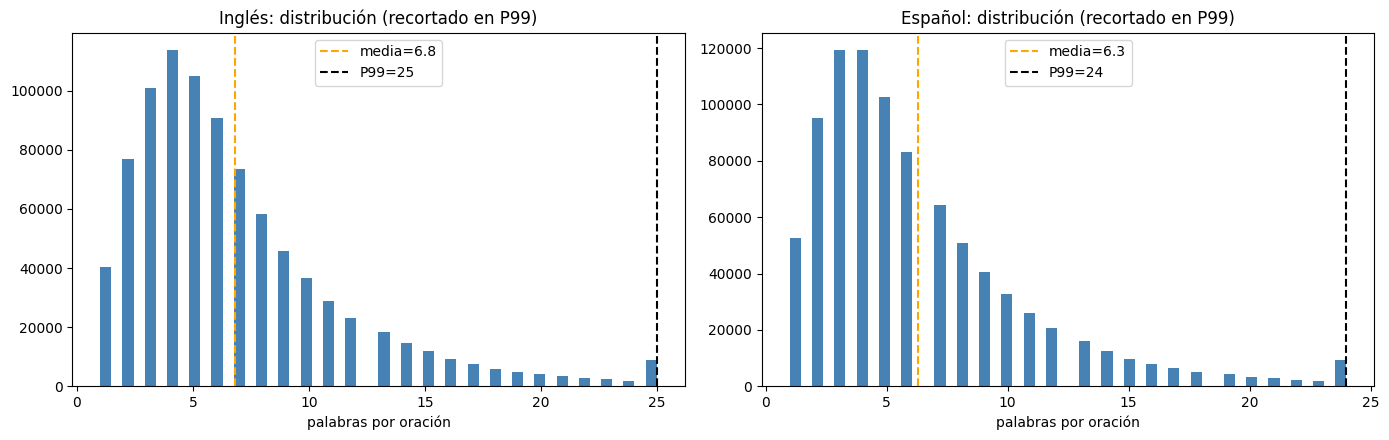


5 pares más largos (por tokens de español):


,english,spanish,english_toks,spanish_toks
5896,I say to myself as I smile at the wall let myself fall it's gonna be all right no matter what they say it's gonna be...,Me digo a mi misma como le sonrío a la pared... me dejo caer... va a estar todo bien... no importa lo que digan... v...,94,175
572829,"[Dance music] [Throws up] [CeCe Peniston's ' Finally'] ¶ Finally, it's happened to me ¶ ¶ right in front of my face ...","¶ Finalmente, me ha ocurrido a mi ¶ ¶ justo frente a mis ojos ¶ ¶ y no lo puedo ocultar. ¶ ¶ Encontrándome al Sr. Pe...",157,146
132378,But when you work for someone like André Luiz Filho... who does excellent work in this part of town... and has propo...,Pero cuando uno trabaja para un candidato igual aAndré Luiz Filho... que hace un trabajo bonito en nuestra región......,97,126
327335,That was one of the key things that spurred this research... realizing that it was too dangerous for humans to go in...,Ese fue uno de los puntos claves que estimuló esta investigación... darnos cuenta de que era demasiado peligroso par...,86,100
272624,Many of my clients are found not guilty at the CSRT Tribunals. And then the Military thinks that doesn't sound so go...,"Mi cliente puede resultó ser inocente ... en los tribunales, pero el ejército cree que ... no suena muy bien, que se...",35,94


In [10]:
# =========================
# LONGITUD DE LAS ORACIONES (OpenSubtitles, post-filtros de calidad)
# =========================

import matplotlib.pyplot as plt

TOK_RE_TMP = re.compile(r"\w+(?:'\w+)*|[^\w\s]")   # mismo criterio que en Tatoeba, para poder comparar

df_clean_1m["english_words"] = df_clean_1m["english"].str.split().str.len()
df_clean_1m["spanish_words"] = df_clean_1m["spanish"].str.split().str.len()
df_clean_1m["english_toks"] = df_clean_1m["english"].map(lambda s: len(TOK_RE_TMP.findall(s)))
df_clean_1m["spanish_toks"] = df_clean_1m["spanish"].map(lambda s: len(TOK_RE_TMP.findall(s)))

cols = ["english_words", "spanish_words", "english_toks", "spanish_toks"]
pcts = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
stats_1m = pd.DataFrame({
    c: {
        "min": df_clean_1m[c].min(), "max": df_clean_1m[c].max(),
        "media": df_clean_1m[c].mean(), "mediana": df_clean_1m[c].median(), "std": df_clean_1m[c].std(),
        **{f"P{int(p*100)}": df_clean_1m[c].quantile(p) for p in pcts},
        "P99.9": df_clean_1m[c].quantile(0.999),
    } for c in cols
}).round(2)
print("=== Estadísticos de longitud (OpenSubtitles) ===")
display(stats_1m)

print("\n=== Comparación rápida con Tatoeba (medias) ===")
print(f"Tatoeba   -> EN: 6.20 palabras | ES: 5.97 palabras")
print(f"OpenSubs  -> EN: {df_clean_1m['english_words'].mean():.2f} palabras | ES: {df_clean_1m['spanish_words'].mean():.2f} palabras")

# --- Cobertura acumulada (tokens estimados) ---
both_max = df_clean_1m[["english_toks", "spanish_toks"]].max(axis=1)
cover_1m = pd.DataFrame({"L": [10, 15, 20, 25, 30, 40, 50, 75, 100]})
cover_1m["AMBOS <= L (%)"] = [(both_max <= L).mean() * 100 for L in cover_1m["L"]]
print("\n=== Cobertura acumulada ===")
display(cover_1m.round(3))

# --- Histogramas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for j, (lang, col) in enumerate([("Inglés", "english_words"), ("Español", "spanish_words")]):
    x = df_clean_1m[col]
    p99 = x.quantile(0.99)
    axes[j].hist(x.clip(upper=p99), bins=50, color="steelblue")
    axes[j].axvline(x.mean(), color="orange", ls="--", label=f"media={x.mean():.1f}")
    axes[j].axvline(p99, color="black", ls="--", label=f"P99={p99:.0f}")
    axes[j].set_title(f"{lang}: distribución (recortado en P99)")
    axes[j].set_xlabel("palabras por oración"); axes[j].legend()
plt.tight_layout(); plt.show()

print("\n5 pares más largos (por tokens de español):")
display(df_clean_1m.nlargest(5, "spanish_toks")[["english", "spanish", "english_toks", "spanish_toks"]])

In [11]:
# =========================
# FILTRO DE LONGITUD (OpenSubtitles)
# =========================
MAX_TOKENS_1M = 30

n_before = len(df_clean_1m)
max_len = df_clean_1m[["english_toks", "spanish_toks"]].max(axis=1)
keep = max_len <= MAX_TOKENS_1M
df_clean_1m = df_clean_1m[keep].reset_index(drop=True)
n_after = len(df_clean_1m)

print(f"Antes del filtro de longitud : {n_before:,}")
print(f"Eliminados (> {MAX_TOKENS_1M} tokens)  : {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)")
print(f"Después                      : {n_after:,}")

print(f"\n=== Resumen total desde el crudo ===")
print(f"Original (muestra)      : 1,000,000")
print(f"Tras filtros de calidad : 889,282  (-11.07%)")
print(f"Tras filtro de longitud : {n_after:,}  (-{(1_000_000 - n_after)/1_000_000*100:.2f}% del original)")

Antes del filtro de longitud : 889,282
Eliminados (> 30 tokens)  : 9,204 (1.03%)
Después                      : 880,078

=== Resumen total desde el crudo ===
Original (muestra)      : 1,000,000
Tras filtros de calidad : 889,282  (-11.07%)
Tras filtro de longitud : 880,078  (-11.99% del original)


In [12]:
# =========================
# DIAGNÓSTICO DE GRUPOS (OpenSubtitles, sin leakage)
# =========================
def norm_key(s):
    return re.sub(r"[^\w\s]", "", s.lower()).strip()

key_en_1m = df_clean_1m["english"].map(norm_key)
key_es_1m = df_clean_1m["spanish"].map(norm_key)

parent = {}
def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for e, s in zip(key_en_1m, key_es_1m):
    union(("en", e), ("es", s))

gid = {}
df_clean_1m["group"] = [gid.setdefault(find(("en", e)), len(gid)) for e in key_en_1m]

sizes_1m = df_clean_1m.groupby("group").size()
print("=== Diagnóstico de grupos ===")
print(f"Pares totales                        : {len(df_clean_1m):,}")
print(f"Claves inglesas normalizadas distintas: {key_en_1m.nunique():,}")
print(f"Grupos (componentes conexas EN<->ES)  : {len(sizes_1m):,}")
print(f"Tamaño de grupo -> mediana: {sizes_1m.median():.0f} | media: {sizes_1m.mean():.2f} | "
      f"P99: {sizes_1m.quantile(0.99):.0f} | máx: {sizes_1m.max():,}")
print(f"Grupos de 1 fila: {(sizes_1m == 1).sum():,} ({(sizes_1m == 1).mean()*100:.1f}% de los grupos)")
print("\nLos 15 grupos más grandes (nº de filas):", sizes_1m.sort_values(ascending=False).head(15).tolist())
print(f"Filas en el grupo más grande: {sizes_1m.max():,} ({sizes_1m.max()/len(df_clean_1m)*100:.3f}% del dataset)")

top = sizes_1m.idxmax()
print("\nEjemplos del grupo más grande:")
display(df_clean_1m[df_clean_1m["group"] == top][["english", "spanish"]].sample(min(10, sizes_1m.max()), random_state=SEED))

# --- ¿Cuánto del dataset queda "atrapado" en los grupos grandes? ---
big_groups = sizes_1m[sizes_1m >= 50]
print(f"\nGrupos con >=50 filas: {len(big_groups):,} | filas que representan: {big_groups.sum():,} ({big_groups.sum()/len(df_clean_1m)*100:.2f}% del dataset)")

=== Diagnóstico de grupos ===
Pares totales                        : 880,078
Claves inglesas normalizadas distintas: 764,380
Grupos (componentes conexas EN<->ES)  : 702,730
Tamaño de grupo -> mediana: 1 | media: 1.25 | P99: 3 | máx: 133,217
Grupos de 1 fila: 681,379 (97.0% de los grupos)

Los 15 grupos más grandes (nº de filas): [133217, 68, 64, 62, 60, 54, 54, 46, 45, 45, 43, 42, 41, 41, 40]
Filas en el grupo más grande: 133,217 (15.137% del dataset)

Ejemplos del grupo más grande:


,english,spanish
563745,Fuck off.,Oh cállate..!
296141,"Yes, sir.",Vaya al servicio del material.
259708,Quite so.,Exactamente.
154860,no.,Rindete.
240943,It worked.,Funciono.
145559,I didn't know.,Yo no sabía.
831262,Evelyn.,Evelyn
537619,Bitch?,¿Perro?
231311,Sorry.,Perdona...
426258,That's all of it.,Eso es todo.



Grupos con >=50 filas: 7 | filas que representan: 133,579 (15.18% del dataset)


In [13]:
# =========================
# DIAGNÓSTICO DE GRUPOS — CORREGIDO: agrupar solo por inglés
# =========================
gid_en = {}
df_clean_1m["group"] = [gid_en.setdefault(k, len(gid_en)) for k in key_en_1m]

sizes_1m = df_clean_1m.groupby("group").size()
print("=== Diagnóstico de grupos (solo por inglés) ===")
print(f"Pares totales                        : {len(df_clean_1m):,}")
print(f"Grupos (= claves inglesas distintas)  : {len(sizes_1m):,}")
print(f"Tamaño de grupo -> mediana: {sizes_1m.median():.0f} | media: {sizes_1m.mean():.2f} | "
      f"P99: {sizes_1m.quantile(0.99):.0f} | máx: {sizes_1m.max():,}")
print(f"Grupos de 1 fila: {(sizes_1m == 1).sum():,} ({(sizes_1m == 1).mean()*100:.1f}% de los grupos)")
print("\nLos 15 grupos más grandes:", sizes_1m.sort_values(ascending=False).head(15).tolist())
print(f"Filas en el grupo más grande: {sizes_1m.max():,} ({sizes_1m.max()/len(df_clean_1m)*100:.3f}% del dataset)")

top = sizes_1m.idxmax()
print("\nEjemplos del grupo más grande:")
display(df_clean_1m[df_clean_1m["group"] == top][["english", "spanish"]].sample(min(10, sizes_1m.max()), random_state=SEED))

big_groups = sizes_1m[sizes_1m >= 50]
print(f"\nGrupos con >=50 filas: {len(big_groups):,} | filas que representan: {big_groups.sum():,} ({big_groups.sum()/len(df_clean_1m)*100:.2f}%)")

=== Diagnóstico de grupos (solo por inglés) ===
Pares totales                        : 880,078
Grupos (= claves inglesas distintas)  : 764,380
Tamaño de grupo -> mediana: 1 | media: 1.15 | P99: 4 | máx: 689
Grupos de 1 fila: 733,110 (95.9% de los grupos)

Los 15 grupos más grandes: [689, 557, 531, 518, 514, 430, 364, 312, 312, 302, 295, 259, 252, 236, 235]
Filas en el grupo más grande: 689 (0.078% del dataset)

Ejemplos del grupo más grande:


,english,spanish
287268,Yeah?,¿Si?
831394,Yeah.,"Sí, lo que quieras."
257395,yeah?,¿Sí?
357417,Yeah.,¿Pena?
338187,Yeah.,Sí...
203234,Yeah?,Diga.
787789,Yeah,Si.
168088,Yeah.,sí.
695579,Yeah.,¿Bien?
256509,Yeah!,¡Sí!



Grupos con >=50 filas: 206 | filas que representan: 22,657 (2.57%)


In [15]:
from google.colab import drive
drive.mount("/content/drive")
PROJ = "/content/drive/MyDrive/Proyecto_traductor"   # misma carpeta que usa tu compañero

Mounted at /content/drive


In [16]:
# =========================
# SPLIT POR GRUPOS (OpenSubtitles)
# =========================
TRAIN_FRAC, VAL_FRAC = 0.90, 0.05
rng = np.random.default_rng(SEED)

perm = rng.permutation(sizes_1m.index.to_numpy())
cum = np.cumsum(sizes_1m.loc[perm].to_numpy()) / len(df_clean_1m)
split_of_group = np.where(cum <= TRAIN_FRAC, "train",
                  np.where(cum <= TRAIN_FRAC + VAL_FRAC, "val", "test"))
df_clean_1m["split"] = df_clean_1m["group"].map(dict(zip(perm, split_of_group)))
df_clean_1m["key_en"] = key_en_1m.loc[df_clean_1m.index] if key_en_1m.index.equals(df_clean_1m.index) else df_clean_1m["english"].map(norm_key)
df_clean_1m["en_len"] = df_clean_1m["english_toks"]
df_clean_1m["es_len"] = df_clean_1m["spanish_toks"]

print("=== Tamaños ===")
summary = df_clean_1m.groupby("split").agg(
    filas=("english", "size"), grupos=("group", "nunique"),
    media_en=("en_len", "mean"), media_es=("es_len", "mean"),
    p95_en=("en_len", lambda s: s.quantile(0.95)), p95_es=("es_len", lambda s: s.quantile(0.95)),
).loc[["train", "val", "test"]]
summary["% filas"] = summary["filas"] / len(df_clean_1m) * 100
display(summary.round(3))

print("\n=== Verificaciones anti-leakage ===")
print("Grupos en más de un split:", int((df_clean_1m.groupby("group")["split"].nunique() > 1).sum()))
for col, name in [("english", "inglés exacto"), ("key_en", "inglés normalizado")]:
    sets = {sp: set(df_clean_1m.loc[df_clean_1m["split"] == sp, col]) for sp in ["train", "val", "test"]}
    print(f"{name:20s} train∩val={len(sets['train'] & sets['val'])} | "
          f"train∩test={len(sets['train'] & sets['test'])} | val∩test={len(sets['val'] & sets['test'])}")

# Informativo (no forzado): cuánto se repite el ESPAÑOL exacto entre splits -- esperado > 0, es aceptable
sets_es = {sp: set(df_clean_1m.loc[df_clean_1m["split"] == sp, "spanish"]) for sp in ["train", "val", "test"]}
print(f"\n(informativo) español exacto compartido: train∩val={len(sets_es['train'] & sets_es['val']):,} | "
      f"train∩test={len(sets_es['train'] & sets_es['test']):,}")

# --- Guardar en Drive ---
SPLIT_DIR_1M = os.path.join(PROJ, "data", "opensubtitles_1m", "splits")
os.makedirs(SPLIT_DIR_1M, exist_ok=True)
for sp in ["train", "val", "test"]:
    d = df_clean_1m[df_clean_1m["split"] == sp]
    with open(os.path.join(SPLIT_DIR_1M, f"{sp}.tsv"), "w", encoding="utf-8", newline="\n") as f:
        for e, s, g in zip(d["english"], d["spanish"], d["group"]):
            f.write(f"{e}\t{s}\t{g}\n")
print("\nGuardado en:", SPLIT_DIR_1M, "->", os.listdir(SPLIT_DIR_1M))

=== Tamaños ===


,filas,grupos,media_en,media_es,p95_en,p95_es,% filas
split,,,,,,,
train,792070,687375,8.351,7.952,18.0,17.0,90.0
val,44004,38278,8.366,7.972,19.0,18.0,5.0
test,44004,38727,8.385,7.988,18.0,17.0,5.0



=== Verificaciones anti-leakage ===
Grupos en más de un split: 0
inglés exacto        train∩val=0 | train∩test=0 | val∩test=0
inglés normalizado   train∩val=0 | train∩test=0 | val∩test=0

(informativo) español exacto compartido: train∩val=3,658 | train∩test=3,714

Guardado en: /content/drive/MyDrive/Proyecto_traductor/data/opensubtitles_1m/splits -> ['train.tsv', 'val.tsv', 'test.tsv']


In [17]:
# =========================
# TOKENIZACIÓN + VOCABULARIOS (OpenSubtitles, solo con train)
# =========================
import os, re, csv, collections, gc
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
PROJ = "/content/drive/MyDrive/Proyecto_traductor"
SPLIT_DIR_1M = os.path.join(PROJ, "data", "opensubtitles_1m", "splits")

# Fallback: recarga desde disco si el kernel se reinició
if "df_clean_1m" not in globals() or "split" not in df_clean_1m.columns:
    def load_split(name):
        rows = []
        with open(os.path.join(SPLIT_DIR_1M, f"{name}.tsv"), encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) >= 2:
                    rows.append((parts[0], parts[1]))
        d = pd.DataFrame(rows, columns=["english", "spanish"])
        d["split"] = name
        return d
    df_clean_1m = pd.concat([load_split(s) for s in ["train", "val", "test"]], ignore_index=True)
    print("Recargado desde disco:", len(df_clean_1m), "filas")

TOKEN_RE = re.compile(r"\w+(?:'\w+)*|[^\w\s]")   # decisión A, ya validada con Tatoeba
def tokenize(text):
    return TOKEN_RE.findall(text)

train = df_clean_1m[df_clean_1m["split"] == "train"]
val   = df_clean_1m[df_clean_1m["split"] == "val"]

train_en_tok = train["english"].map(tokenize)
train_es_tok = train["spanish"].map(tokenize)
val_en_tok   = val["english"].map(tokenize)
val_es_tok   = val["spanish"].map(tokenize)

cnt_en = collections.Counter(t for ts in train_en_tok for t in ts)
cnt_es = collections.Counter(t for ts in train_es_tok for t in ts)
print(f"Tipos en train -> EN: {len(cnt_en):,} | ES: {len(cnt_es):,}")

PAD, UNK, SOS, EOS = "<PAD>", "<UNK>", "<SOS>", "<EOS>"
SPECIALS = [PAD, UNK, SOS, EOS]

def build_vocab(counter, min_freq):
    words = [w for w, c in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])) if c >= min_freq]
    itos = SPECIALS + words
    return {w: i for i, w in enumerate(itos)}, itos

def unk_stats(token_lists, stoi):
    total = unk = sents = 0
    for ts in token_lists:
        u = sum(1 for t in ts if t not in stoi)
        total += len(ts); unk += u; sents += (u > 0)
    return unk / total * 100, sents / len(token_lists) * 100

rows = []
for mf in [1, 2, 3, 5, 10]:
    s_en, _ = build_vocab(cnt_en, mf)
    s_es, _ = build_vocab(cnt_es, mf)
    en_tok, en_sent = unk_stats(val_en_tok, s_en)
    es_tok, es_sent = unk_stats(val_es_tok, s_es)
    rows.append({"min_freq": mf, "vocab EN": len(s_en), "vocab ES": len(s_es),
                 "val EN %UNK": en_tok, "val EN %oraciones c/UNK": en_sent,
                 "val ES %UNK": es_tok, "val ES %oraciones c/UNK": es_sent})
print("\n=== min_freq vs <UNK> en validación ===")
display(pd.DataFrame(rows).round(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tipos en train -> EN: 118,426 | ES: 157,225

=== min_freq vs <UNK> en validación ===


,min_freq,vocab EN,vocab ES,val EN %UNK,val EN %oraciones c/UNK,val ES %UNK,val ES %oraciones c/UNK
0,1,118430,157229,0.970,7.229,1.315,9.313
1,2,56800,76084,1.448,10.517,2.006,13.760
2,3,41054,54487,1.798,12.787,2.535,17.014
3,5,28160,37161,2.350,16.155,3.311,21.475
4,10,17413,22512,3.324,21.793,4.700,28.850


In [18]:
# =========================
# VOCABULARIO FINAL (min_freq=5) + DIAGNÓSTICO DE <UNK> + EXPORTACIÓN
# =========================
import json

MIN_FREQ = 5
stoi_en, itos_en = build_vocab(cnt_en, MIN_FREQ)
stoi_es, itos_es = build_vocab(cnt_es, MIN_FREQ)

print(f"=== Vocabularios finales (min_freq={MIN_FREQ}) ===")
print(f"EN: {len(itos_en):,} entradas | ES: {len(itos_es):,} entradas")
print("Primeras entradas EN:", itos_en[:14])
print("Primeras entradas ES:", itos_es[:14])
for sp in [PAD, UNK, SOS, EOS]:
    assert stoi_en[sp] == stoi_es[sp] == SPECIALS.index(sp)

# --- ¿Qué palabras quedan como <UNK> en validación? ---
def categorize(t):
    if any(ch.isdigit() for ch in t): return "contiene dígitos"
    if t[0].isupper(): return "capitalizada (nombre propio / inicio)"
    return "minúscula (palabra rara)"

for lang, toks, stoi in [("EN", val_en_tok, stoi_en), ("ES", val_es_tok, stoi_es)]:
    uw = collections.Counter(t for ts in toks for t in ts if t not in stoi)
    total = sum(uw.values())
    cats = collections.Counter()
    for w, c in uw.items():
        cats[categorize(w)] += c
    print(f"\n[{lang}] {total:,} tokens <UNK> en validación ({len(uw):,} palabras distintas)")
    print("  por categoría:", {k: f"{v/total*100:.1f}%" for k, v in cats.most_common()})
    print("  top 20:", uw.most_common(20))

# --- Exportar ---
VOCAB_DIR_1M = os.path.join(PROJ, "vocabularios_opensubtitles_1m")
os.makedirs(VOCAB_DIR_1M, exist_ok=True)

with open(os.path.join(VOCAB_DIR_1M, "vocab_english.json"), "w", encoding="utf-8") as f:
    json.dump(stoi_en, f, ensure_ascii=False, indent=2)
with open(os.path.join(VOCAB_DIR_1M, "vocab_spanish.json"), "w", encoding="utf-8") as f:
    json.dump(stoi_es, f, ensure_ascii=False, indent=2)
with open(os.path.join(VOCAB_DIR_1M, "itos_english.json"), "w", encoding="utf-8") as f:
    json.dump(itos_en, f, ensure_ascii=False, indent=2)
with open(os.path.join(VOCAB_DIR_1M, "itos_spanish.json"), "w", encoding="utf-8") as f:
    json.dump(itos_es, f, ensure_ascii=False, indent=2)

vocab_config = {
    "MAX_TOKENS": 30,
    "MAX_SEQ_LEN": 32,   # 30 + <SOS> + <EOS>
    "MIN_FREQ": MIN_FREQ,
    "VOCAB_SIZE_EN": len(itos_en),
    "VOCAB_SIZE_ES": len(itos_es),
    "SPECIAL_TOKENS": {"<PAD>": 0, "<UNK>": 1, "<SOS>": 2, "<EOS>": 3},
    "CORPUS": "OpenSubtitles v2018 (muestra de 1M, tras filtros -> 880,078 pares)",
}
with open(os.path.join(VOCAB_DIR_1M, "vocab_config.json"), "w", encoding="utf-8") as f:
    json.dump(vocab_config, f, ensure_ascii=False, indent=2)

print(f"\nGuardado en: {VOCAB_DIR_1M}")
print(os.listdir(VOCAB_DIR_1M))

=== Vocabularios finales (min_freq=5) ===
EN: 28,160 entradas | ES: 37,161 entradas
Primeras entradas EN: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', '.', ',', '?', 'I', 'you', 'the', 'to', 'a', '!', 'of']
Primeras entradas ES: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', '.', ',', 'que', 'de', '?', '¿', 'a', 'la', 'no', 'el']

[EN] 8,652 tokens <UNK> en validación (8,121 palabras distintas)
  por categoría: {'capitalizada (nombre propio / inicio)': '54.7%', 'minúscula (palabra rara)': '43.7%', 'contiene dígitos': '1.6%'}
  top 20: [('Poo', 6), ('S2', 5), ('Subbing', 5), ('Tuppence', 4), ('Motherfuck', 4), ('Stakes', 4), ('bup', 4), ('Secretaries', 3), ('Denied', 3), ('Arcade', 3), ('horrid', 3), ('Anubis', 3), ('herald', 3), ('Rey', 3), ('overestimate', 3), ('dreidel', 3), ('Traitors', 3), ('coastline', 3), ('Auf', 3), ('Programs', 3)]

[ES] 11,613 tokens <UNK> en validación (10,940 palabras distintas)
  por categoría: {'minúscula (palabra rara)': '51.9%', 'capitalizada (nombre propio / inicio)': '4

In [19]:
# =========================
# BENCHMARK: tiempo por batch/época ANTES de lanzar el entrenamiento completo
# =========================
import torch, time
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "sin GPU")

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
MAX_TOKENS = 30

class TranslationDataset(Dataset):
    def __init__(self, tsv_file, stoi_src, stoi_tgt, max_len=MAX_TOKENS):
        self.pairs = []
        with open(tsv_file, encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) >= 2:
                    self.pairs.append((parts[0], parts[1]))
        self.stoi_src, self.stoi_tgt, self.max_len = stoi_src, stoi_tgt, max_len

    def __len__(self): return len(self.pairs)

    def encode(self, text, stoi):
        ids = [stoi.get(t, UNK_IDX) for t in tokenize(text)[:self.max_len]]
        ids = [SOS_IDX] + ids + [EOS_IDX]
        return ids + [PAD_IDX] * (self.max_len + 2 - len(ids))

    def __getitem__(self, i):
        s, t = self.pairs[i]
        return (torch.tensor(self.encode(s, self.stoi_src)),
                torch.tensor(self.encode(t, self.stoi_tgt)))

BATCH_SIZE = 64
train_ds_1m = TranslationDataset(os.path.join(SPLIT_DIR_1M, "train.tsv"), stoi_en, stoi_es)
train_loader_1m = DataLoader(train_ds_1m, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Train: {len(train_ds_1m):,} pares | {len(train_loader_1m):,} batches por época")

# --- Medir tiempo de 50 batches reales (sin entrenar nada todavía, solo cargar) ---
t0 = time.time()
for i, (src, tgt) in enumerate(train_loader_1m):
    src, tgt = src.to(DEVICE), tgt.to(DEVICE)
    if i >= 49:
        break
dt = time.time() - t0
batches_total = len(train_loader_1m)
print(f"\n50 batches (solo carga+transferencia a GPU): {dt:.1f}s -> {dt/50*1000:.0f} ms/batch")
print(f"Estimado por época (solo datos, sin forward/backward): {dt/50*batches_total/60:.1f} minutos")

Dispositivo: cpu | sin GPU
Train: 792,070 pares | 12,377 batches por época

50 batches (solo carga+transferencia a GPU): 1.5s -> 30 ms/batch
Estimado por época (solo datos, sin forward/backward): 6.1 minutos


In [4]:
# =========================
# ARQUITECTURA TRANSFORMER (idéntica a la usada con Tatoeba)
# =========================
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        Q = self.w_q(q).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.w_o(out)

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1, max_len=100):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model
    def forward(self, src, mask):
        x = self.embed(src) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_enc(x))
        for layer in self.layers:
            x = layer(x, mask)
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, enc_out, src_mask, tgt_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1, max_len=100):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model
    def forward(self, tgt, enc_out, src_mask, tgt_mask):
        x = self.embed(tgt) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_enc(x))
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return self.fc_out(x)

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, n_heads=8, d_ff=512,
                 n_layers=3, dropout=0.1, max_len=100, pad_idx=0):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.pad_idx = pad_idx
    def make_src_mask(self, src):
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)
    def make_tgt_mask(self, tgt):
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        L = tgt.size(1)
        sub_mask = torch.tril(torch.ones((L, L), device=tgt.device)).bool()
        return pad_mask & sub_mask
    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encoder(src, src_mask)
        return self.decoder(tgt, enc_out, src_mask, tgt_mask)

In [6]:
# =========================
# RECARGA COMPLETA TRAS REINICIO POR GPU
# =========================
import os, re, json, time
import torch
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

drive.mount("/content/drive")
PROJ = "/content/drive/MyDrive/Proyecto_traductor"
SPLIT_DIR_1M = os.path.join(PROJ, "data", "opensubtitles_1m", "splits")
VOCAB_DIR_1M = os.path.join(PROJ, "vocabularios_opensubtitles_1m")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "SIN GPU")

with open(os.path.join(VOCAB_DIR_1M, "vocab_english.json"), encoding="utf-8") as f:
    stoi_en = json.load(f)
with open(os.path.join(VOCAB_DIR_1M, "vocab_spanish.json"), encoding="utf-8") as f:
    stoi_es = json.load(f)
with open(os.path.join(VOCAB_DIR_1M, "vocab_config.json"), encoding="utf-8") as f:
    vocab_cfg = json.load(f)

MAX_TOKENS = vocab_cfg["MAX_TOKENS"]
PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
print(f"Vocab EN: {len(stoi_en):,} | Vocab ES: {len(stoi_es):,} | MAX_TOKENS: {MAX_TOKENS}")

TOKEN_RE = re.compile(r"\w+(?:'\w+)*|[^\w\s]")
def tokenize(text):
    return TOKEN_RE.findall(text)

class TranslationDataset(Dataset):
    def __init__(self, tsv_file, stoi_src, stoi_tgt, max_len=MAX_TOKENS):
        self.pairs = []
        with open(tsv_file, encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) >= 2:
                    self.pairs.append((parts[0], parts[1]))
        self.stoi_src, self.stoi_tgt, self.max_len = stoi_src, stoi_tgt, max_len
    def __len__(self): return len(self.pairs)
    def encode(self, text, stoi):
        ids = [stoi.get(t, UNK_IDX) for t in tokenize(text)[:self.max_len]]
        ids = [SOS_IDX] + ids + [EOS_IDX]
        return ids + [PAD_IDX] * (self.max_len + 2 - len(ids))
    def __getitem__(self, i):
        s, t = self.pairs[i]
        return (torch.tensor(self.encode(s, self.stoi_src)),
                torch.tensor(self.encode(t, self.stoi_tgt)))

BATCH_SIZE = 64
train_ds_1m = TranslationDataset(os.path.join(SPLIT_DIR_1M, "train.tsv"), stoi_en, stoi_es)
train_loader_1m = DataLoader(train_ds_1m, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Train: {len(train_ds_1m):,} pares | {len(train_loader_1m):,} batches por época")

Mounted at /content/drive
Dispositivo: cuda | Tesla T4
Vocab EN: 28,160 | Vocab ES: 37,161 | MAX_TOKENS: 30
Train: 792,070 pares | 12,377 batches por época


In [7]:
# =========================
# BENCHMARK REAL: con GPU y con forward+backward del Transformer
# =========================
import torch, time
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "SIN GPU -- revisa el entorno de ejecución")
assert DEVICE.type == "cuda", "No hay GPU activa. Cambia el entorno de ejecución antes de seguir."

# Reutiliza aquí la clase Transformer ya definida en el notebook de entrenamiento de tu compañero
# (cópiala si este notebook no la tiene todavía)

model = Transformer(
    src_vocab_size=len(stoi_en), tgt_vocab_size=len(stoi_es),
    d_model=256, n_heads=8, d_ff=1024, n_layers=3, dropout=0.15,
    max_len=100, pad_idx=PAD_IDX
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

model.train()
t0 = time.time()
for i, (src, tgt) in enumerate(train_loader_1m):
    src, tgt = src.to(DEVICE), tgt.to(DEVICE)
    tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
    logits = model(src, tgt_in)
    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if i >= 49:
        break
dt = time.time() - t0
batches_total = len(train_loader_1m)
print(f"\n50 batches (forward+backward reales): {dt:.1f}s -> {dt/50*1000:.0f} ms/batch")
print(f"Estimado por época completa: {dt/50*batches_total/60:.1f} minutos")
print(f"Estimado para 10 épocas: {dt/50*batches_total*10/60:.1f} minutos ({dt/50*batches_total*10/3600:.1f} horas)")

Dispositivo: cuda | Tesla T4

50 batches (forward+backward reales): 5.3s -> 106 ms/batch
Estimado por época completa: 21.8 minutos
Estimado para 10 épocas: 218.2 minutos (3.6 horas)


In [ ]:
# =========================
# ENTRENAMIENTO (OpenSubtitles 1M) — con early stopping y checkpoint de recuperación
# =========================
import time
import matplotlib.pyplot as plt

D_MODEL, N_HEADS, D_FF, N_LAYERS, DROPOUT, MAX_POS_LEN = 256, 8, 1024, 3, 0.15, 100

model = Transformer(
    src_vocab_size=len(stoi_en), tgt_vocab_size=len(stoi_es),
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS,
    dropout=DROPOUT, max_len=MAX_POS_LEN, pad_idx=PAD_IDX
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {n_params:,}")

MODEL_DIR_1M = os.path.join(PROJ, "modelos_opensubtitles_1m")
os.makedirs(MODEL_DIR_1M, exist_ok=True)
with open(os.path.join(MODEL_DIR_1M, "model_config.json"), "w", encoding="utf-8") as f:
    json.dump({"d_model": D_MODEL, "n_heads": N_HEADS, "d_ff": D_FF, "n_layers": N_LAYERS,
               "dropout": DROPOUT, "max_len": MAX_POS_LEN}, f, indent=2)

val_ds_1m = TranslationDataset(os.path.join(SPLIT_DIR_1M, "val.tsv"), stoi_en, stoi_es)
val_loader_1m = DataLoader(val_ds_1m, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)
WARMUP_STEPS = 4000   # más alto que Tatoeba (2000), porque hay ~18x más pasos por época
def lr_lambda(step):
    step = max(1, step)
    if step < WARMUP_STEPS: return step / WARMUP_STEPS
    return max(0.05, (WARMUP_STEPS / step) ** 0.5)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            if is_train:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item()
    return total_loss / len(loader)

MAX_EPOCHS = 15          # techo, no un número fijo a ciegas
PATIENCE = 3             # si no mejora en 3 épocas seguidas, se detiene
BEST_PATH = os.path.join(MODEL_DIR_1M, "best_model.pth")
LAST_PATH = os.path.join(MODEL_DIR_1M, "last_checkpoint.pth")

best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": []}

print("\n" + "="*60 + "\nENTRENAMIENTO (early stopping activo)\n" + "="*60)
for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()
    train_loss = run_epoch(train_loader_1m, is_train=True)
    val_loss = run_epoch(val_loader_1m, is_train=False)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    torch.save({"model_state": model.state_dict(), "epoch": epoch,
                "optimizer_state": optimizer.state_dict(), "history": history}, LAST_PATH)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_PATH)
        epochs_no_improve = 0
        mark = "   [BEST]"
    else:
        epochs_no_improve += 1
        mark = f"   [sin mejora: {epochs_no_improve}/{PATIENCE}]"

    dt = time.time() - t0
    print(f"Época {epoch:02d}/{MAX_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.6f} | {dt/60:.1f} min{mark}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping en la época {epoch} (sin mejora por {PATIENCE} épocas).")
        break

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.4)
plt.title("OpenSubtitles 1M — curva de entrenamiento")
plt.show()

print(f"\nMejor val loss: {best_val_loss:.4f} | Guardado en: {BEST_PATH}")

Parámetros entrenables: 31,802,153

ENTRENAMIENTO (early stopping activo)
Época 01/15 | Train: 4.7373 | Val: 4.1050 | LR: 0.000568 | 18.9 min   [BEST]
